# Network summary comparisons

Comparisons between summaries of neural activity networks in infant and adult mice.


In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import nb_config
import nb_plotting
import nb_utils
import numpy as np
import pandas as pd
import plotly.express as px

from ngmd import dataset, permutation_tests, plotting, utils

%reload_ext autoreload
%autoreload 2

warnings.simplefilter(action="ignore", category=FutureWarning)

# Dataset path as a global variable. Remember to set the correct path to the
# dataset in `notebooks/nb_config.py`
DATA_DIR = nb_config.DATA_DIR

# Choose a similarity computation method
SIMILARITY_METHOD = "sttc_percentiles"
# SIMILARITY_METHOD = "zscores"

# Set a connectivity threshold to be investigated in more detail
CONNECT_THRESH = nb_utils.select_default_connect_thresh(SIMILARITY_METHOD)

# Keep results only for sessions marked as "good" in the dataset. Sessions that were marked as bad are those for which at least some of the analysis metrics were to far away from what one would see the days right before and after. You can still load the results for all sessions by setting the variable below to False.
KEEP_ONLY_GOOD_SESSIONS = True
# KEEP_ONLY_GOOD_SESSIONS = False

# Load results for subsampled networks. Set this to None to load the results for
# the full networks in each session.
SUBSAMPLE_SIZE = 250
# SUBSAMPLE_SIZE = None

There is no environment variable named NGMD_DATA. Try setting DATA_DIR directly or assign first a value to variable NGMD_DATA in your bash_profile (or zshrc) file.
There is no environment variable named NGMD_MODELS. Try setting MODELS_DIR directly or assign first a value to variable NGMD_MODELS in your bash_profile (or zshrc) file.


## Loading the animal dataset


In [2]:
animal_dataset = dataset.AnimalDataset(DATA_DIR)

## Scalar summaries of network properties

Each experiment session can be linked to a neural activity graphs built from the measured calcium fluorescence data. The first thing we may do to quantify properties of these graphs is to compile some standard network science summaries. Here are the summaries we will record.

- **Number of connected components**.
- **Density**: fraction of all possible edges.
- **Transitivity**: fraction of all possible triangles.
- [**Average clustering coefficient**](https://en.wikipedia.org/wiki/Clustering_coefficient).
  - The local clustering coefficient of a node quantifies how close it and its neighbors are to being a clique. Small-world networks have high average clustering coefficients
- **Size of the largest connected component**.
  - Normalized by number of nodes
- **Average shortest path length** of the largest connected component.
- **Small-worldness** of the largest connected component.
  - Small-world coefficient from Telesford et al. (2011).
  - To compute the coefficient, one first compares the average clustering coefficient of the network to the same summary of an equivalent lattice network, then compares the average shortest path length of the network to the same summary of an equivalent random network. The small-world coefficient is then the difference of ratios issues from these two comparisons.
  - This coefficient should range between -1 and 1. Values close to zero indicate graphs with more small-world characteristics. Positive values indicate a graph with more random characteristics. Negative values indicate a graph with more regular, or lattice-like, characteristics.
- **Radius** and **Diameter** of the largest connected component (a.k.a. minimum and maximum eccentricity, respectively).
  - The eccentricity of a node is the maximum distance from this node to all other nodes in the graph.
- **Median Page Rank**
  - The page rank of a node measures the node's "importance" in the network via the number of edges that connect to it. Quality of the connections also counts: if a node receives connections from a node with large page rank, then the former node will tend to have large page rank as well. The median of the page ranks in the network is the summary we record for each neural activity graph. Being a quantile, we know that the higher the median, the more nodes are considered important.

I have pre-computed the network summaries above for some connectivity thresholds. Let us load these summaries and compare how these summaries change as the connectivity threshold increases. We should expect quantities like the number of connected components to decrease, whereas the density should decrease. But these changes need not happen at the same rate for different groups of mice. We will present the summaries reduced by development stage groups, because we would like to catch distinctions across networks of infant and adult mice, not necessarily across individual mice.

_Remarks_:

- You may recompute these summaries for a given connectivity threshold by yourself using the script `scripts/network_summaries.py`.


In [3]:
thresholds = [90, 95, 96, 97, 98, 98, 99]

dfs = []
for t in thresholds:
    file_name = "network_summaries_{}".format(SIMILARITY_METHOD)
    file_name += "_connect_thresh={:.1f}".format(t)
    if SUBSAMPLE_SIZE is not None:
        file_name += "_subsample_size={}".format(SUBSAMPLE_SIZE)
    file_name += ".csv"
    summary_path = os.path.join(DATA_DIR, "analysis_files", file_name)
    if os.path.exists(summary_path):
        df = pd.read_csv(summary_path)
        df["connect_thresh"] = t

        # Small-worldness is in a separate file
        sm_path = os.path.join(
            DATA_DIR,
            "analysis_files",
            "small_worldness_{}_connect_thresh={:.1f}".format(SIMILARITY_METHOD, t)
            + ".csv",
        )
        if os.path.exists(sm_path):
            sm_df = pd.read_csv(sm_path)
            df["small_worldness"] = sm_df["small_worldness"]
        else:
            df["small_worldness"] = np.nan

        # Sort animal_id and dev_stage, in ascending order
        df = df.sort_values(["animal_id", "dev_stage"])
        dfs.append(df)

summaries_df = pd.concat(dfs, ignore_index=True)
summaries_df.head()

,animal_id,session_date,dev_stage,num_neurons,num_conn_comp,density,transitivity,avg_clust,size_largest_cc,avg_short_path_length,radius,diameter,median_page_rank,connect_thresh,small_worldness
0,DON-002865,20210210,230,634,2.0,0.065526,0.462707,0.3605,249.0,2.639834,4.0,5.0,0.003883,95,NaN
1,DON-002865,20210211,231,338,4.0,0.046426,0.304400,0.3985,246.5,2.697381,4.0,6.0,0.003620,95,NaN
2,DON-002865,20210212,232,378,6.0,0.045799,0.263095,0.3495,244.0,2.677543,4.0,6.0,0.003729,95,NaN
3,DON-002865,20210213,233,336,6.0,0.046522,0.334230,0.4000,245.0,2.753811,4.0,6.0,0.003675,95,NaN
4,DON-002865,20210214,234,381,6.0,0.046779,0.358615,0.3970,245.0,2.743767,4.0,6.0,0.003758,95,NaN


Discard rows corresponding to "bad" sessions. These are sessions that were marked as bad during the analysis because their metric was to far away from what one would see the days right before and after. If you comment out the line restricting the data frame only to the good sessions, you'll see some large, unexpected spikes in the day-by-day values plotted in some of the cells below. These are the bad sessions.


In [4]:
if KEEP_ONLY_GOOD_SESSIONS:
    # Keep only the rows corresponding to "good" sessions
    summaries_df = nb_utils.keep_rows_from_good_sessions(summaries_df, animal_dataset)

The development stage windows are defined by quantiles, so that each of the 5 windows have the same number of representatives. You may also define arbitrary windows by specifying the window borders (cuts).


In [5]:
# Use default developmental stage windows
dev_stage_cuts = utils.get_default_dev_stage_cuts()

print("The selected development windows are:")
print("\n".join([label for label in nb_utils.labels_from_cuts(dev_stage_cuts)]))

The selected development windows are:
PDay 15-24
PDay 24-55
PDay 55-90
PDay 90-300


Each network summary table, for each connectivity threshold is recorded as a single dictionary for easy access. For example, `num_neurons[5]['PDay 15-22']` contains the number of neurons for networks in the development window 'PDay 15-22' at connectivity threshold `5`.


In [6]:
num_neurons = {}
num_conn_comp = {}
density = {}
transitivity = {}
avg_clust = {}
size_largest_cc = {}
avg_short_path_length = {}
radius = {}
diameter = {}
median_page_rank = {}
small_worldness = {}

connect_thresh_grouping = summaries_df.groupby(summaries_df["connect_thresh"])

for key, df in connect_thresh_grouping:
    dev_grouping = nb_utils.group_by_dev_interval(df, dev_stage_cuts)

    num_neurons[key] = {}
    num_conn_comp[key] = {}
    density[key] = {}
    transitivity[key] = {}
    avg_clust[key] = {}
    size_largest_cc[key] = {}
    avg_short_path_length[key] = {}
    radius[key] = {}
    diameter[key] = {}
    median_page_rank[key] = {}
    small_worldness[key] = {}

    for dev_key, dev_df in dev_grouping:
        num_neurons[key][dev_key] = dev_df["num_neurons"].values
        num_conn_comp[key][dev_key] = dev_df["num_conn_comp"].values
        density[key][dev_key] = dev_df["density"].values
        transitivity[key][dev_key] = dev_df["transitivity"].values
        avg_clust[key][dev_key] = dev_df["avg_clust"].values
        size_largest_cc[key][dev_key] = (
            dev_df["size_largest_cc"].values / dev_df["num_neurons"].values
        )
        avg_short_path_length[key][dev_key] = dev_df["avg_short_path_length"].values
        radius[key][dev_key] = dev_df["radius"].values
        diameter[key][dev_key] = dev_df["diameter"].values
        median_page_rank[key][dev_key] = dev_df["median_page_rank"].values
        small_worldness[key][dev_key] = dev_df["small_worldness"].values

### Number of neurons

The first of the the summaries, the number of neurons, does not change as we change the connectivity threshold. Hence, we can pick an arbitrary threshold value to display this summary. As we can see, there is some variability in the number of neurons identified in each experimental session of each developmental window. These numbers vary (roughly) between below 250 to above 1000, discounting outliers. Despite the variation, the distributions are very similar across the developmental windows.

On the one hand, the number of identified neurons does not differentiate development windows. On the other hand, we do not need to worry about biases in this regard when comparing different windows.


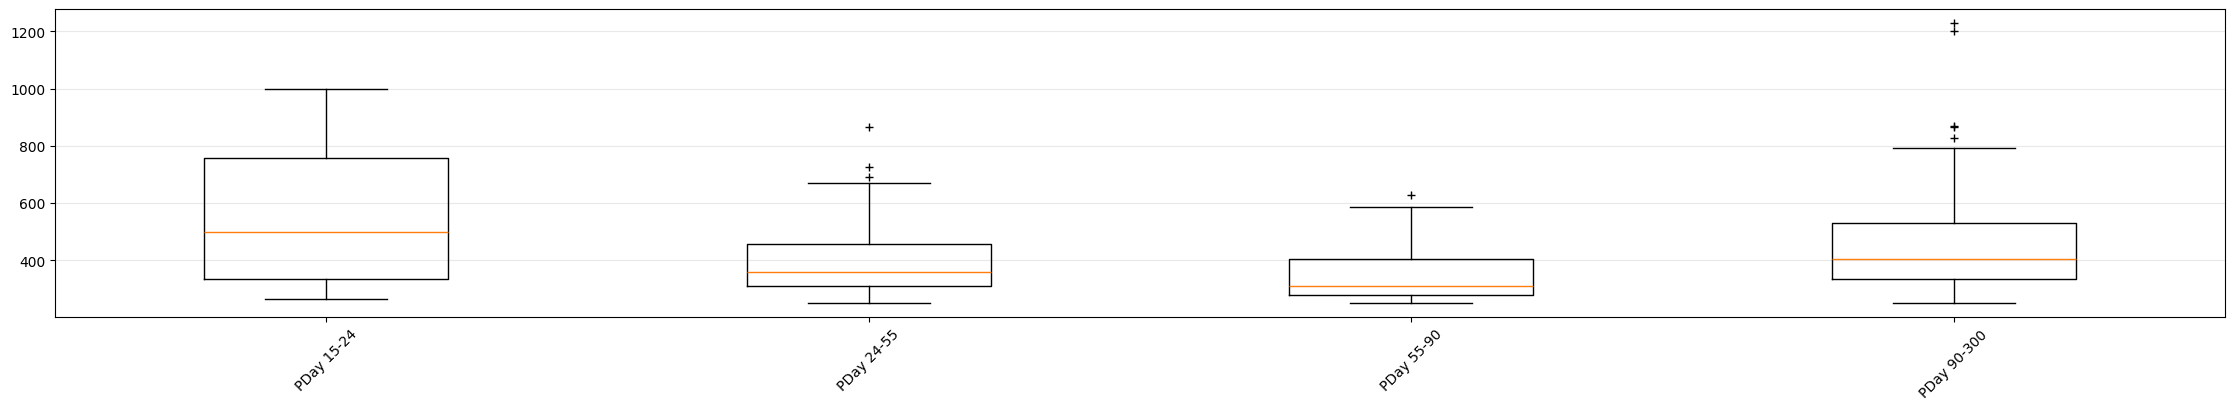

In [7]:
ax = nb_plotting.boxplot_summary({"NA": num_neurons[CONNECT_THRESH]})
ax.set_title("")
plt.show()

Here's a view of how the number of neurons varies per animal throughout development.


In [8]:
summaries_df_connect_thresh = connect_thresh_grouping.get_group(CONNECT_THRESH).copy(
    deep=True
)
fig = px.line(
    summaries_df_connect_thresh, x="dev_stage", y="num_neurons", color="animal_id"
)
fig.show()

### Number of connected components

The plot below shows the distributions of the number of connected components within each of the previously development windows. Each subplot corresponds to a choice of connectivity threshold when creating the graphs from the correlation matrices. When the threshold increases, we see some of what we already expected: the number of connected components tends to increase as well. After all, we are progressively removing "weak" edges from the graphs, which tends to divide the later into more and more connected components. However, the rate at which the number of connected components increases is not necessarily the same for each developmental stage window.


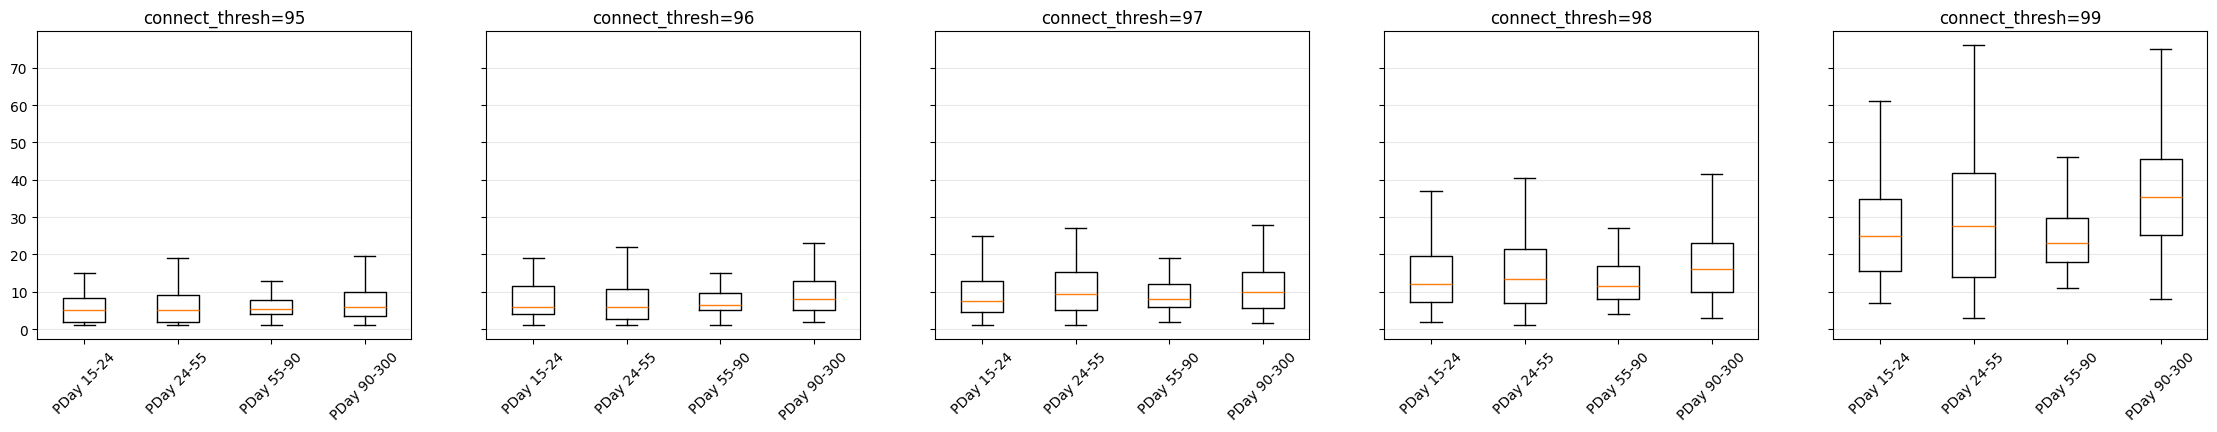

In [9]:
ax = nb_plotting.boxplot_summary(num_conn_comp, showfliers=False)
plt.show()

Let us focus now on `connect_thresh==CONNECT_THRESH` to examine in more detail how the distributions of this particular summary vary across development windows.


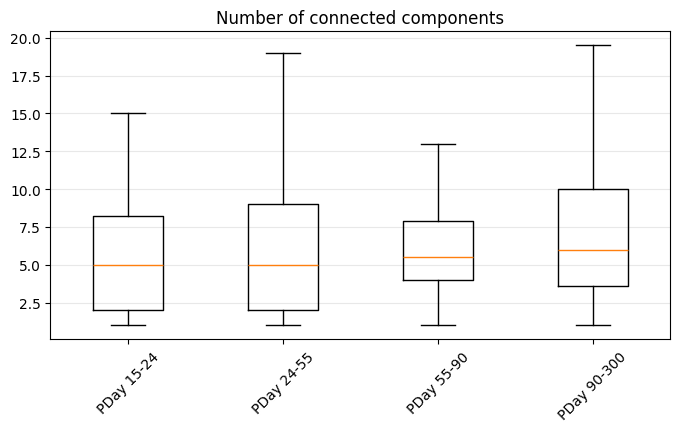

In [10]:
ax = nb_plotting.boxplot_summary(
    {"NA": num_conn_comp[CONNECT_THRESH]}, showfliers=False
)
plt.gcf().set_size_inches(8, 4)
ax.set_title("connect_thresh={:.1f}".format(CONNECT_THRESH))
plt.title("Number of connected components")
plt.savefig("plots/num_conn_comp_boxplot.png", dpi=300)
plt.show()

As we've done with the number of neurons before, we can look at how the number of connected components varies per animal (rather than the summary distributions per developmental window above).


In [11]:
fig = px.line(
    summaries_df_connect_thresh, x="dev_stage", y="num_conn_comp", color="animal_id"
)
fig.show()

We can assess the differences in distributions by running pairwise statistical tests between the development windows.

The test statistics chosen here is the difference-of-means between the distributions of the pair of development windows being tested. The null hypothesis is that the two sets of summaries comes from the same distribution, corresponding to a test statistic equal or close to zero.

To measure how extreme the test statistic between two development windows is, we run a [permutation test](https://en.wikipedia.org/wiki/Permutation_test). The p-value resulting from such test corresponds to the probability of observing a statistic as extreme as the measured one, according to the permutation distribution. In terms of the hypothesis being tested, the p-value should be interpreted as the evidence for an actual difference between the distributions, as provided by the data.

Since we are testing for differences across all pairs of development windows, we perform multiple hypothesis tests in the end. To correct for multiple testing, we then adjust the individual p-values using a Holm step down method using Sidak adjustments. We assume a family-wise-error-rate (FWER) of 0.05 when deciding to reject the null-hypothesis.

In the end, we can obtain a plot like the one below, which can be read as follows. Each cell represents a test of its corresponding row versus its corresponding column. A white cell indicates that we can't conclude that there is a significant difference (i.e. the null hypothesis is accepted at FWER = 0.05). Colors indicate statistically significant differences (at the same FWER) and their direction. Green is for positive, pink for negative. Darker shades of green or pink indicate the magnitude of the difference.


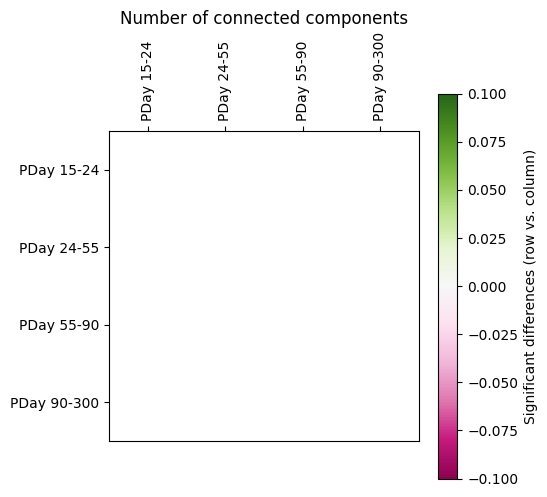

In [12]:
ax, results = permutation_tests.plot_stat_diff(
    num_conn_comp[CONNECT_THRESH],
    return_all=True,
)
ax.set_title("Number of connected components")
plt.savefig("plots/num_conn_comp_permutation_test.png", dpi=300)
plt.show()

We can look at what are the actual (multiple-test-corrected) p-values and statistics of the tests by examining the `results` dictionary. The table below shows which pairs of development windows passed the permutation test, along with their corresponding test statistics and p-values.


In [13]:
nb_utils.format_table_of_passed_tests(results)

,pair,test_stat,p_val


**_Remarks:_**

- This session on the number of connected components is the only one among the summary sessions where we explain what happens in each cell. All the subsequent notebook sessions follow the same narrative, so only the plots are shown. Commentary resumes in the end, with some conclusions.


### Size of the largest connected component


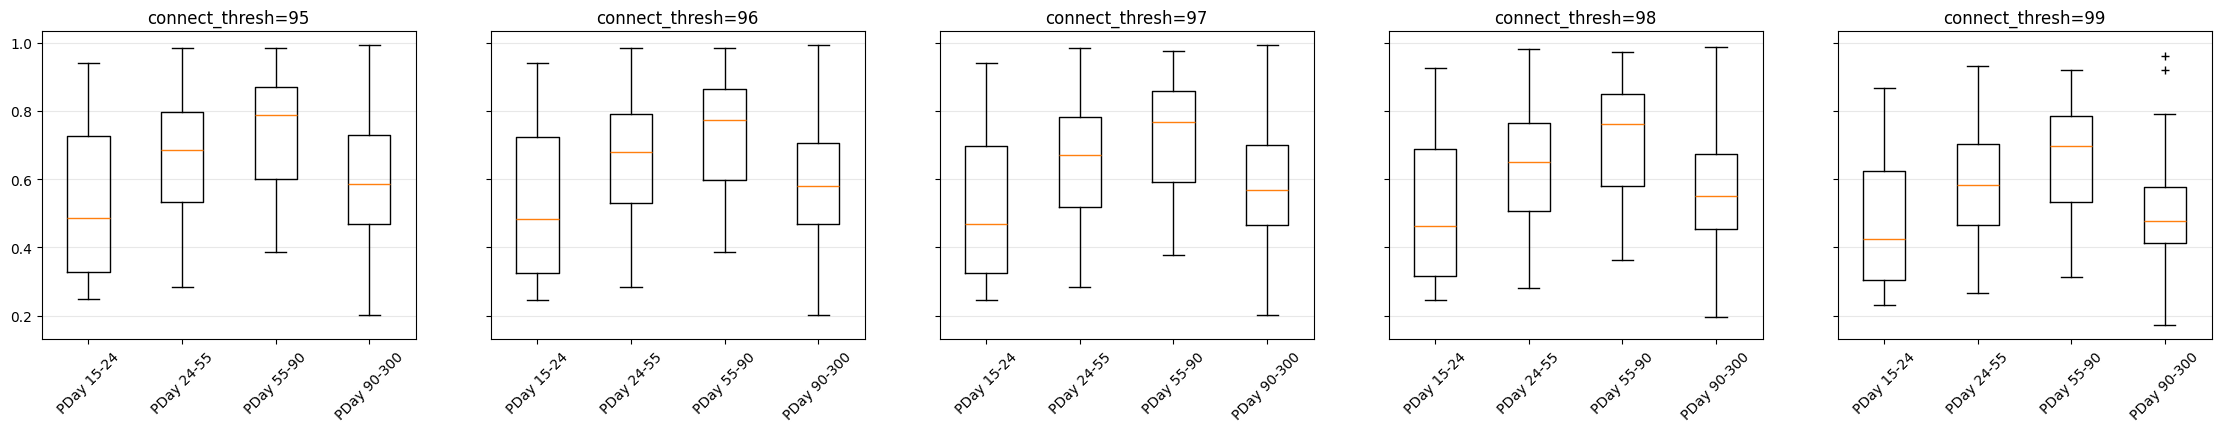

In [14]:
ax = nb_plotting.boxplot_summary(size_largest_cc)
plt.show()

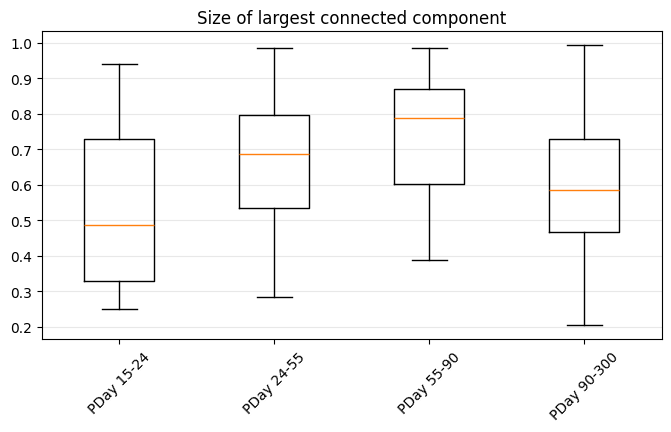

In [15]:
ax = nb_plotting.boxplot_summary(
    {"NA": size_largest_cc[CONNECT_THRESH]}, showfliers=False
)
plt.gcf().set_size_inches(8, 4)
ax.set_title("connect_thresh={:.1f}".format(CONNECT_THRESH))
plt.title("Size of largest connected component")
plt.savefig("plots/size_largest_cc_boxplot.png", dpi=300)
plt.show()

In [16]:
summaries_df_connect_thresh["rel_size_largest_cc"] = (
    summaries_df_connect_thresh["size_largest_cc"]
    / summaries_df_connect_thresh["num_neurons"]
)
fig = px.line(
    summaries_df_connect_thresh,
    x="dev_stage",
    y="rel_size_largest_cc",
    color="animal_id",
)
fig.show()

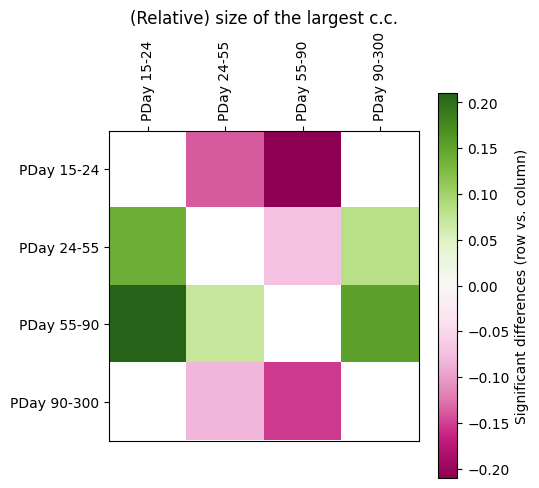

In [17]:
ax, results = permutation_tests.plot_stat_diff(
    size_largest_cc[CONNECT_THRESH],
    return_all=True,
)
ax.set_title("(Relative) size of the largest c.c.")
plt.savefig("plots/size_largest_cc_permutation_test.png", dpi=300)
plt.show()

In [18]:
nb_utils.format_table_of_passed_tests(results)

,pair,test_stat,p_val
0,PDay 15-24 vs. PDay 24-55,-0.138998,0.001199
1,PDay 15-24 vs. PDay 55-90,-0.210247,0.001199
2,PDay 24-55 vs. PDay 55-90,-0.071249,0.012759
3,PDay 24-55 vs. PDay 90-300,0.082787,0.005988
4,PDay 55-90 vs. PDay 90-300,0.154037,0.001199


### Density


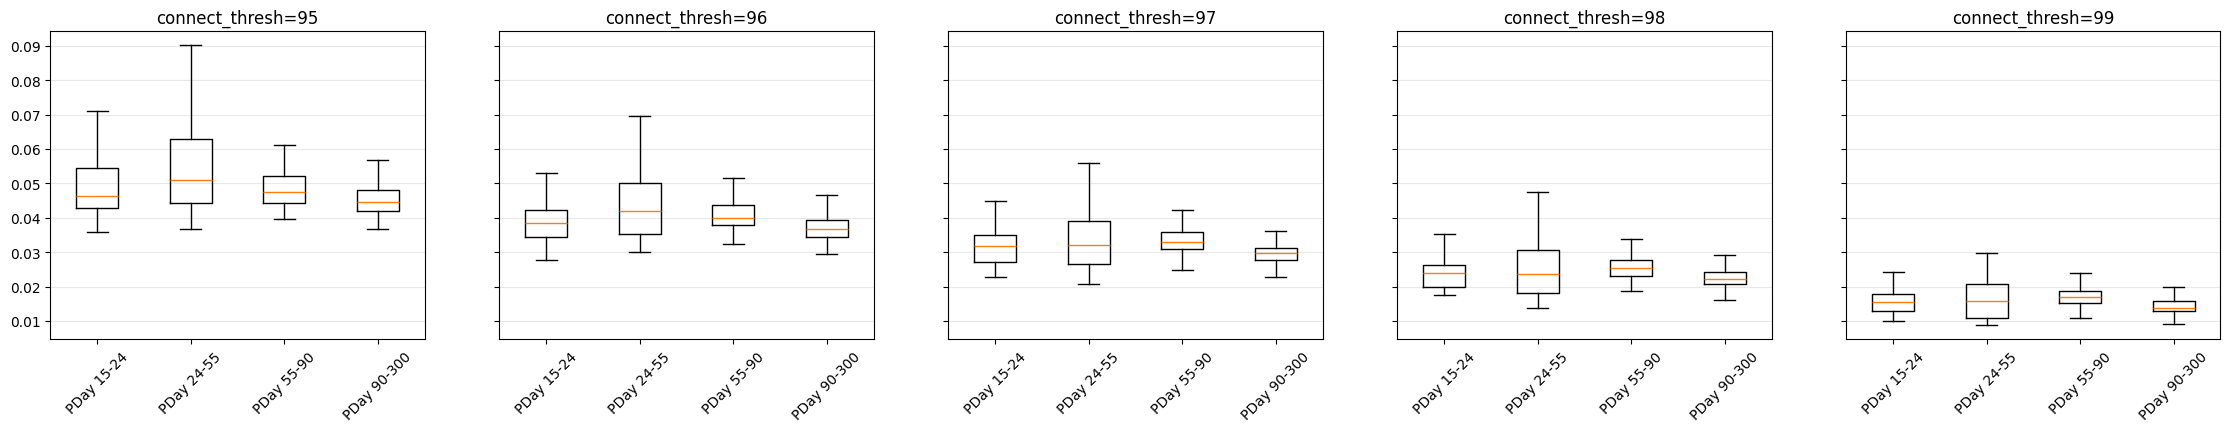

In [19]:
ax = nb_plotting.boxplot_summary(density, showfliers=False)
plt.show()

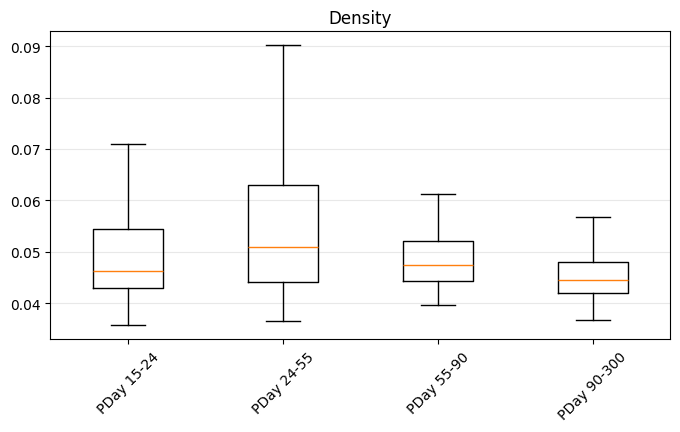

In [20]:
ax = nb_plotting.boxplot_summary({"NA": density[CONNECT_THRESH]}, showfliers=False)
plt.gcf().set_size_inches(8, 4)
ax.set_title("connect_thresh={:.1f}".format(CONNECT_THRESH))
plt.title("Density")
plt.savefig("plots/density_boxplot.png", dpi=300)
plt.show()

In [21]:
fig = px.line(
    summaries_df_connect_thresh, x="dev_stage", y="density", color="animal_id"
)
fig.show()

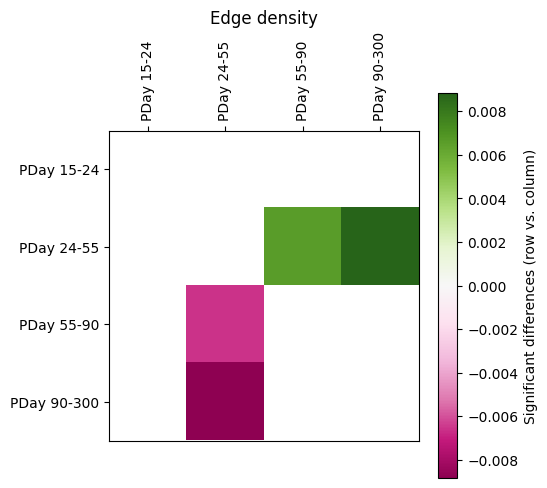

In [22]:
ax, results = permutation_tests.plot_stat_diff(
    density[CONNECT_THRESH],
    return_all=True,
)
ax.set_title("Edge density")
plt.savefig("plots/density_permutation_test.png", dpi=300)
plt.show()

In [23]:
nb_utils.format_table_of_passed_tests(results)

,pair,test_stat,p_val
0,PDay 24-55 vs. PDay 55-90,0.006568,0.008968
1,PDay 24-55 vs. PDay 90-300,0.008837,0.002398


### Transitivity


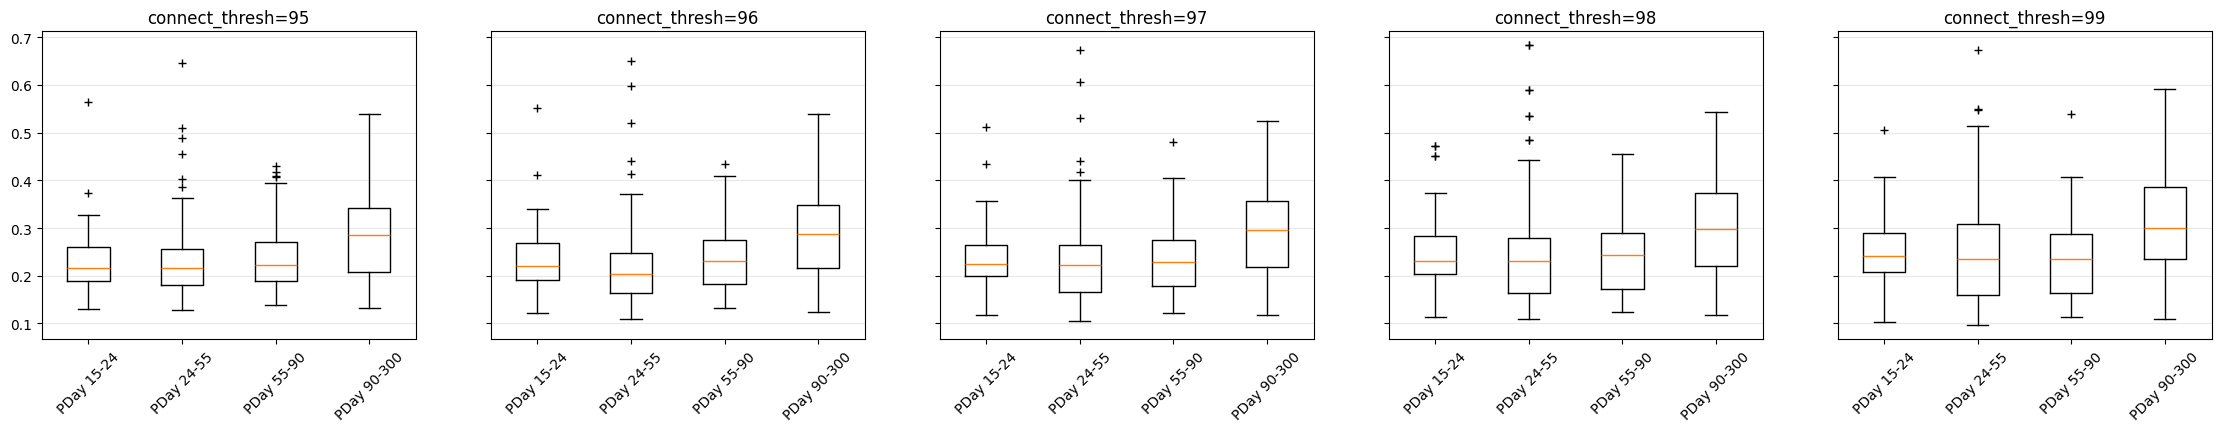

In [24]:
ax = nb_plotting.boxplot_summary(transitivity)
plt.show()

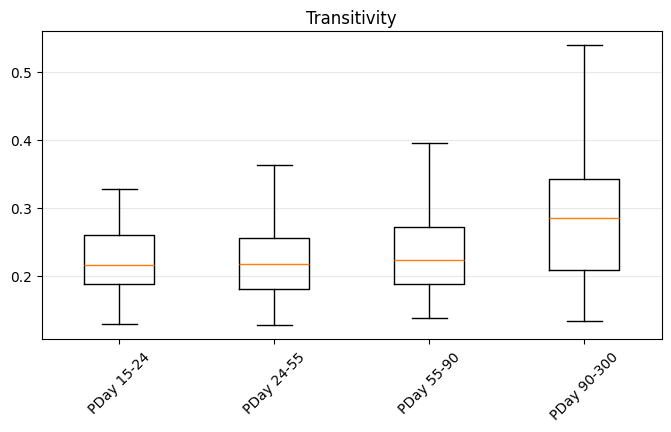

In [25]:
ax = nb_plotting.boxplot_summary({"NA": transitivity[CONNECT_THRESH]}, showfliers=False)
plt.gcf().set_size_inches(8, 4)
ax.set_title("connect_thresh={:.1f}".format(CONNECT_THRESH))
plt.title("Transitivity")
plt.savefig("plots/transitivity_boxplot.png", dpi=300)
plt.show()

In [26]:
fig = px.line(
    summaries_df_connect_thresh, x="dev_stage", y="transitivity", color="animal_id"
)
fig.show()

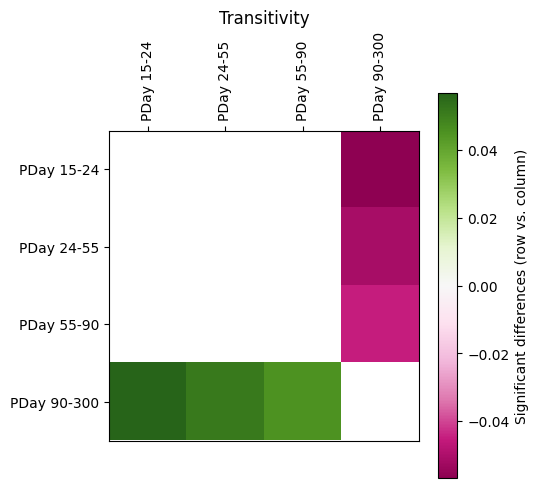

In [27]:
ax, results = permutation_tests.plot_stat_diff(
    transitivity[CONNECT_THRESH],
    return_all=True,
)
ax.set_title("Transitivity")
plt.savefig("plots/transitivity_permutation_test.png", dpi=300)
plt.show()

In [28]:
nb_utils.format_table_of_passed_tests(results)

,pair,test_stat,p_val
0,PDay 15-24 vs. PDay 90-300,-0.056762,0.002996
1,PDay 24-55 vs. PDay 90-300,-0.051311,0.001199
2,PDay 55-90 vs. PDay 90-300,-0.045180,0.002996


### Average clustering


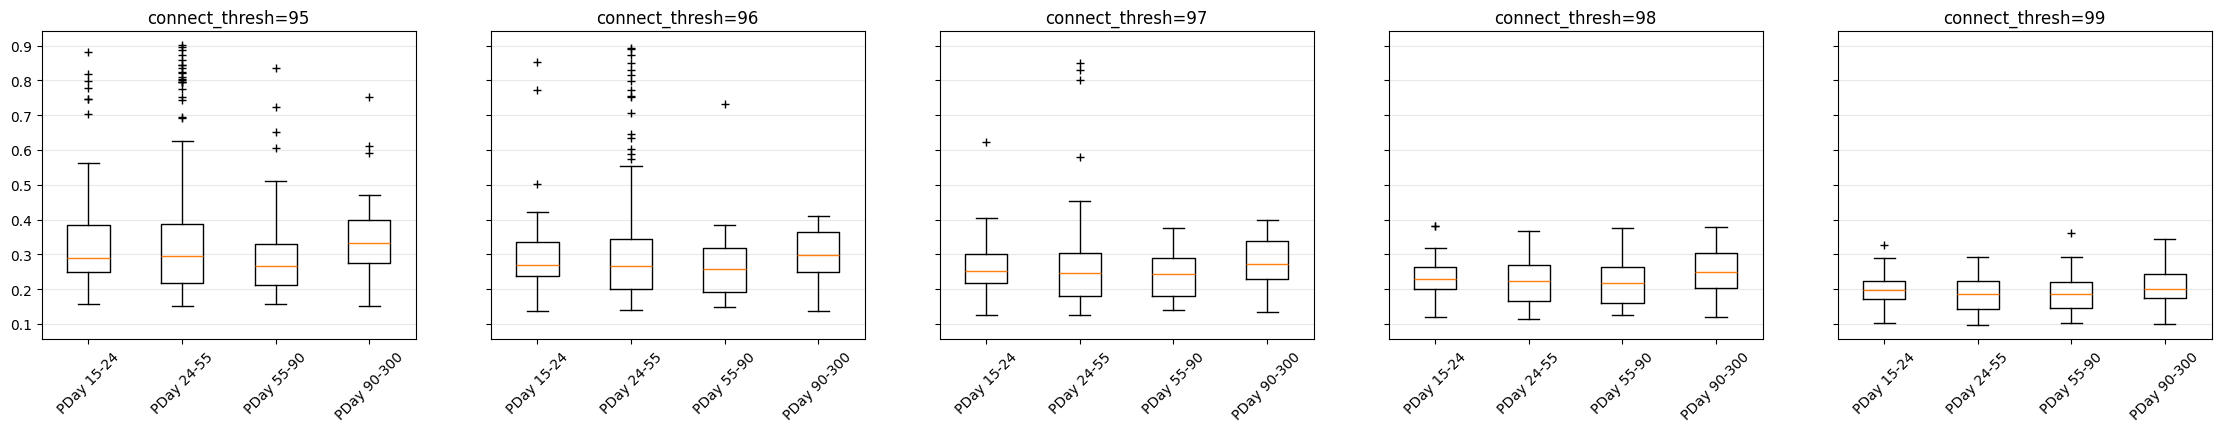

In [29]:
ax = nb_plotting.boxplot_summary(avg_clust)
plt.show()

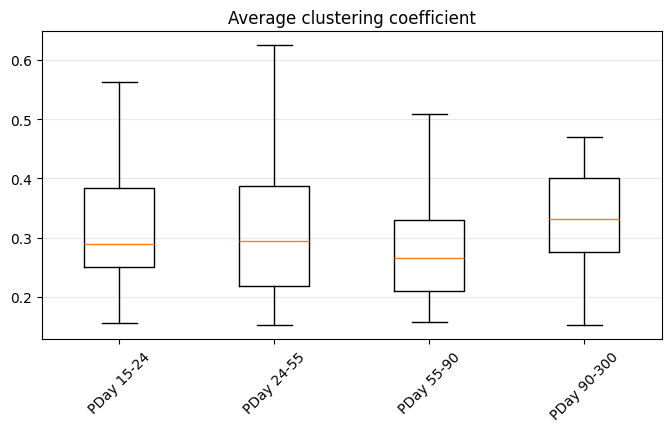

In [30]:
ax = nb_plotting.boxplot_summary({"NA": avg_clust[CONNECT_THRESH]}, showfliers=False)
plt.gcf().set_size_inches(8, 4)
ax.set_title("connect_thresh={:.1f}".format(CONNECT_THRESH))
plt.title("Average clustering coefficient")
plt.savefig("plots/avg_clust_boxplot.png", dpi=300)
plt.show()

In [31]:
fig = px.line(
    summaries_df_connect_thresh, x="dev_stage", y="avg_clust", color="animal_id"
)
fig.show()

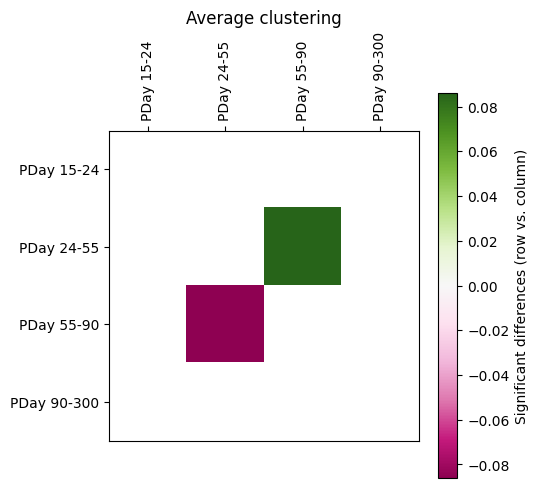

In [32]:
ax, results = permutation_tests.plot_stat_diff(
    avg_clust[CONNECT_THRESH],
    return_all=True,
)
ax.set_title("Average clustering")
plt.savefig("plots/avg_clust_permutation_test.png", dpi=300)
plt.show()

In [33]:
nb_utils.format_table_of_passed_tests(results)

,pair,test_stat,p_val
0,PDay 24-55 vs. PDay 55-90,0.08606,0.009562


### Average shortest path length (of the largest connected component)


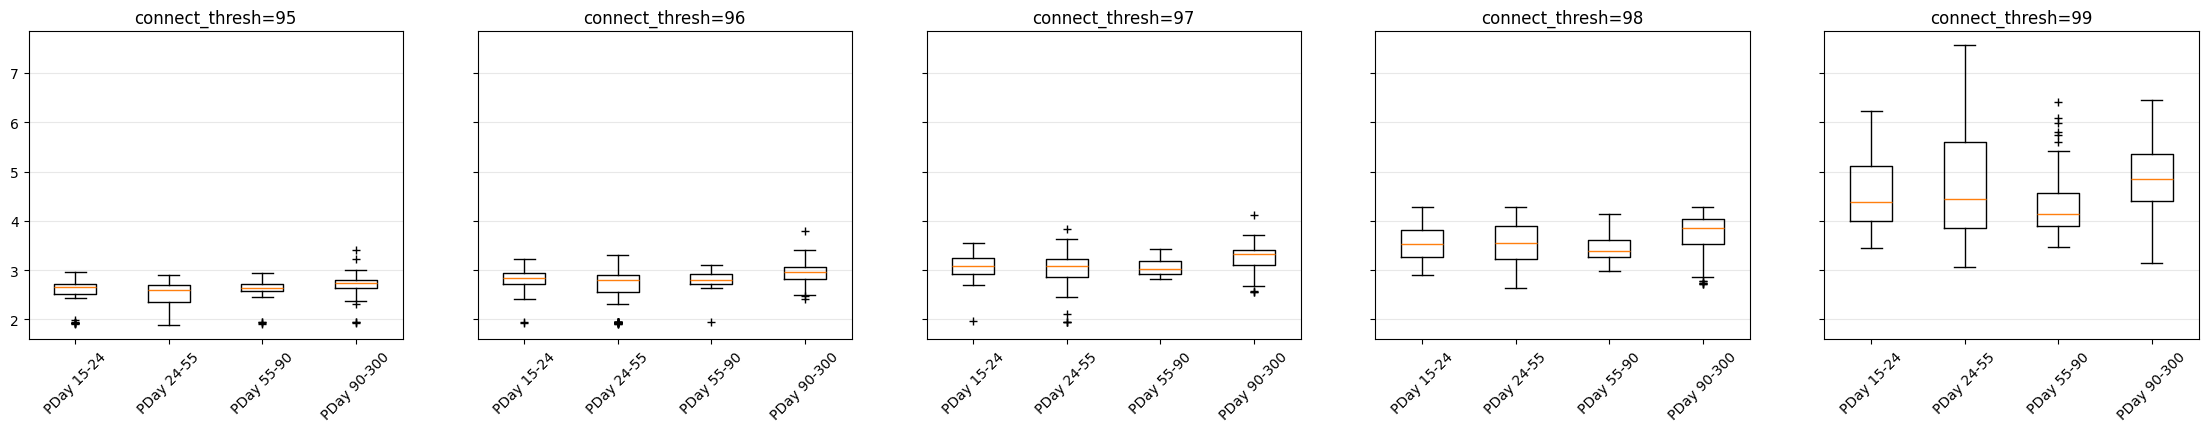

In [34]:
ax = nb_plotting.boxplot_summary(avg_short_path_length)
plt.show()

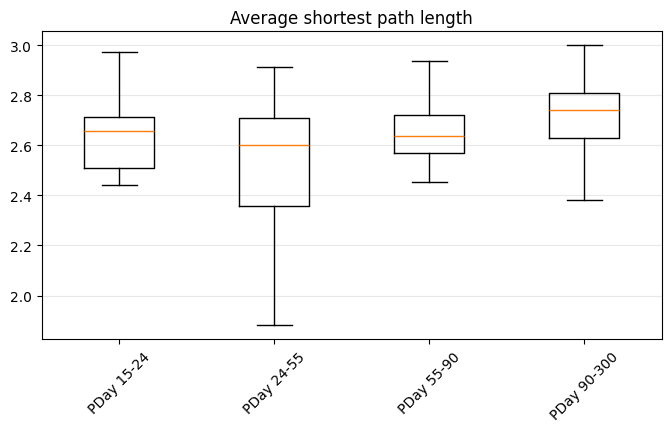

In [35]:
ax = nb_plotting.boxplot_summary(
    {"NA": avg_short_path_length[CONNECT_THRESH]}, showfliers=False
)
plt.gcf().set_size_inches(8, 4)
ax.set_title("connect_thresh={:.1f}".format(CONNECT_THRESH))
plt.title("Average shortest path length")
plt.savefig("plots/avg_short_path_length_boxplot.png", dpi=300)
plt.show()

In [36]:
fig = px.line(
    summaries_df_connect_thresh,
    x="dev_stage",
    y="avg_short_path_length",
    color="animal_id",
)
fig.show()

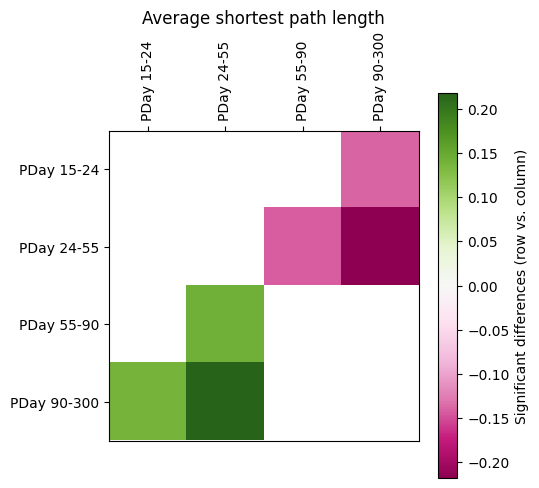

In [37]:
ax, results = permutation_tests.plot_stat_diff(
    avg_short_path_length[CONNECT_THRESH],
    return_all=True,
)
ax.set_title("Average shortest path length")
plt.savefig("plots/avg_short_path_length_permutation_test.png", dpi=300)
plt.show()

In [38]:
nb_utils.format_table_of_passed_tests(results)

,pair,test_stat,p_val
0,PDay 15-24 vs. PDay 90-300,-0.139010,0.018273
1,PDay 24-55 vs. PDay 55-90,-0.141840,0.001998
2,PDay 24-55 vs. PDay 90-300,-0.217756,0.001199


### Small-worldness coefficient (of the largest connected component)


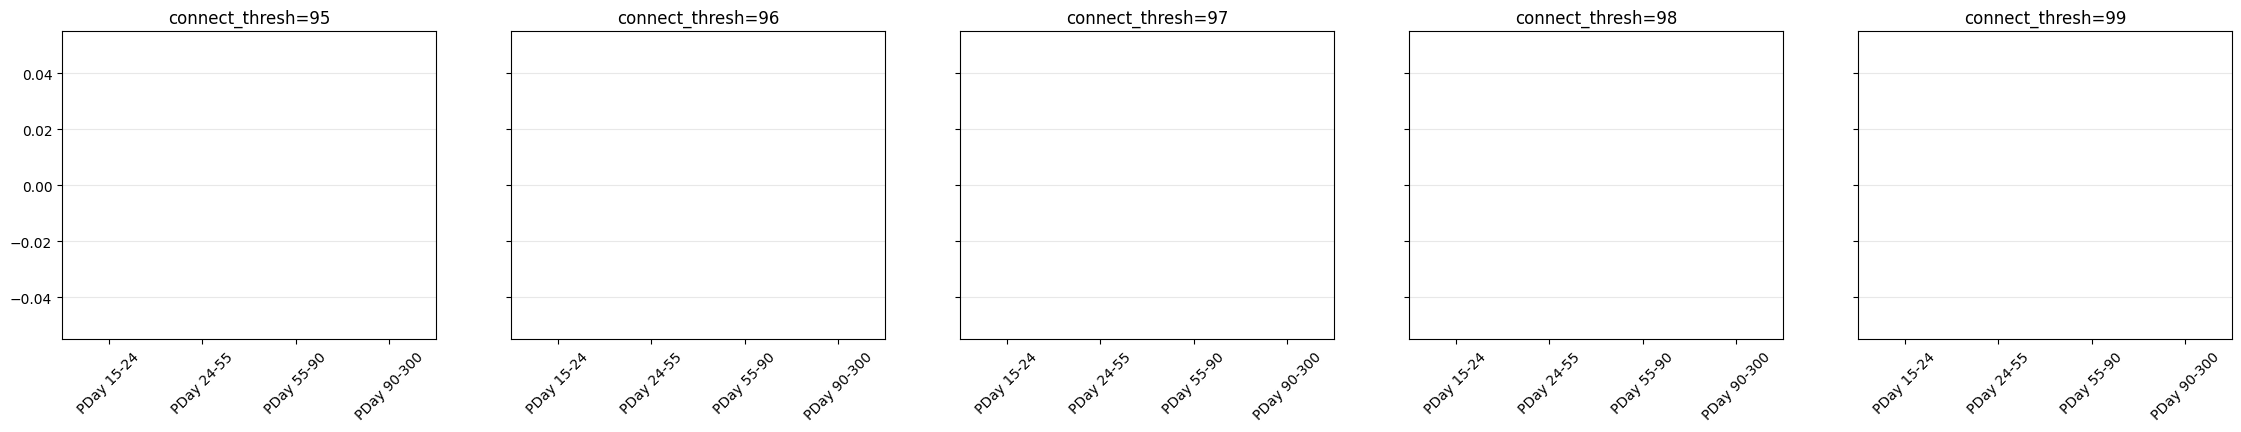

In [39]:
ax = nb_plotting.boxplot_summary(small_worldness)
plt.show()

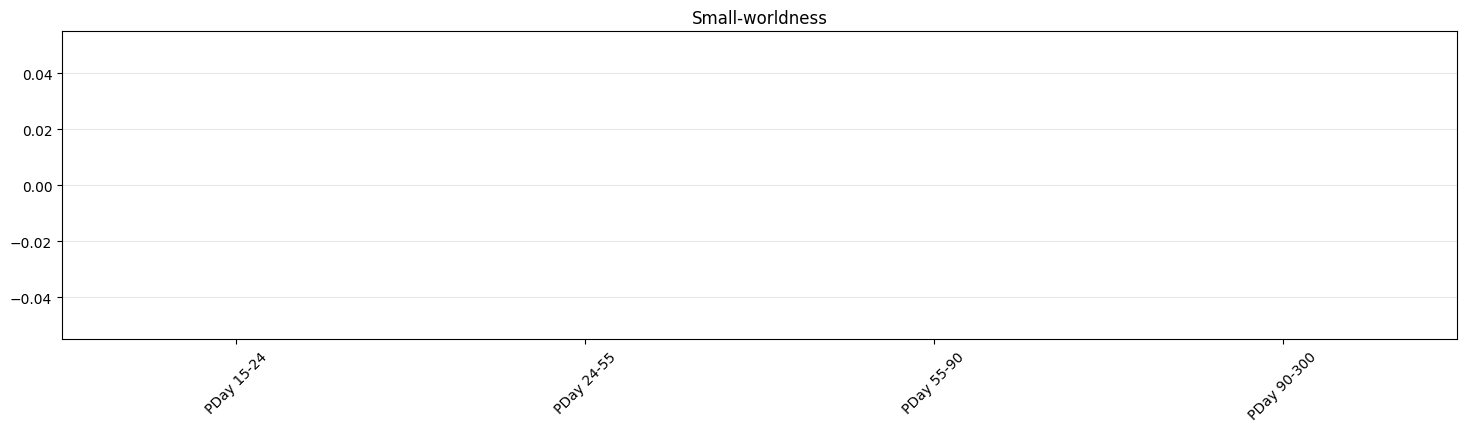

In [40]:
ax = nb_plotting.boxplot_summary(
    {"NA": small_worldness[CONNECT_THRESH]}, showfliers=False
)
plt.gcf().set_size_inches(18, 4)
ax.set_title("connect_thresh={:.1f}".format(CONNECT_THRESH))
plt.title("Small-worldness")
plt.savefig("plots/small_worldness_boxplot.png", dpi=300)
plt.show()

In [41]:
fig = px.line(
    summaries_df_connect_thresh, x="dev_stage", y="small_worldness", color="animal_id"
)
fig.show()

In [42]:
# # Keep only non-NaN values
invalid = False
values = small_worldness[CONNECT_THRESH]
for key in values:
    values[key] = values[key][~np.isnan(values[key])]
    if len(values[key]) == 0:
        invalid = True

if not invalid:
    ax, results = permutation_tests.plot_stat_diff(
        values,
        return_all=True,
    )
    ax.set_title("Small-worldness")
    plt.show()

In [43]:
if not invalid:
    nb_utils.format_table_of_passed_tests(results)

### Radius (of the largest connected component)


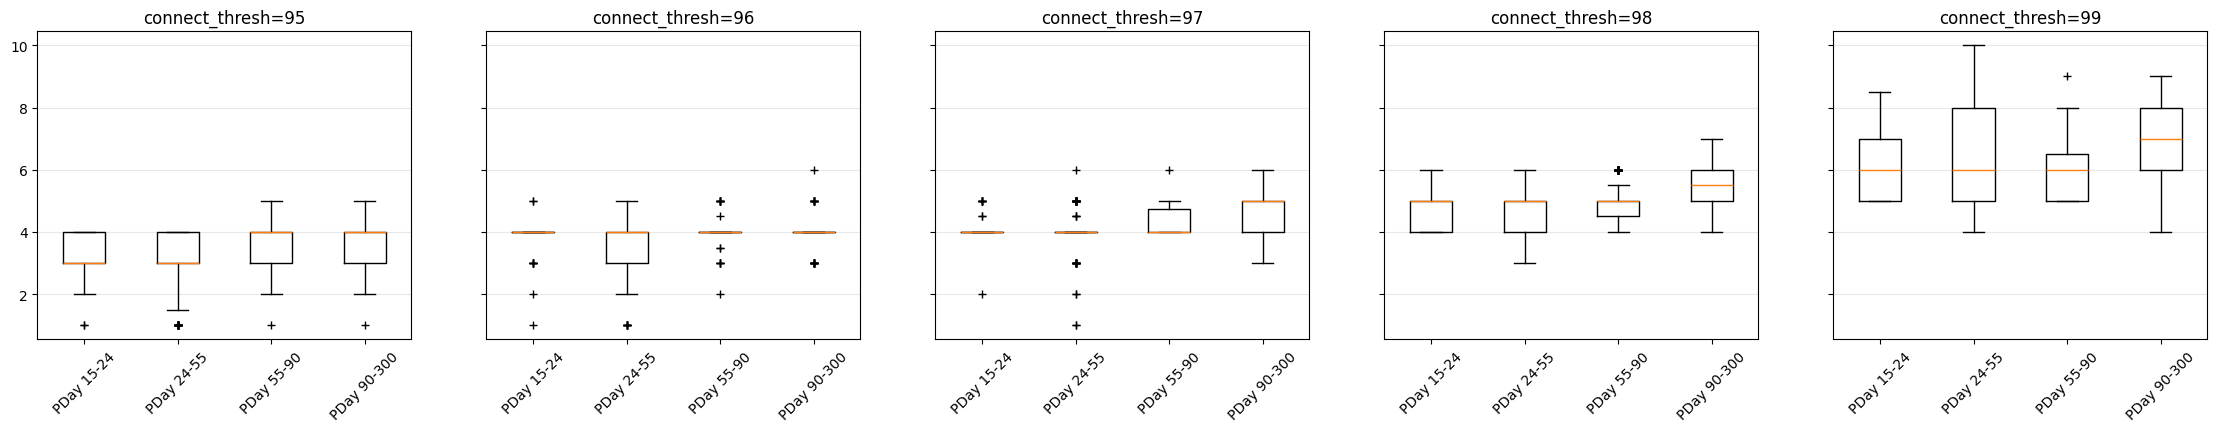

In [44]:
ax = nb_plotting.boxplot_summary(radius)
plt.show()

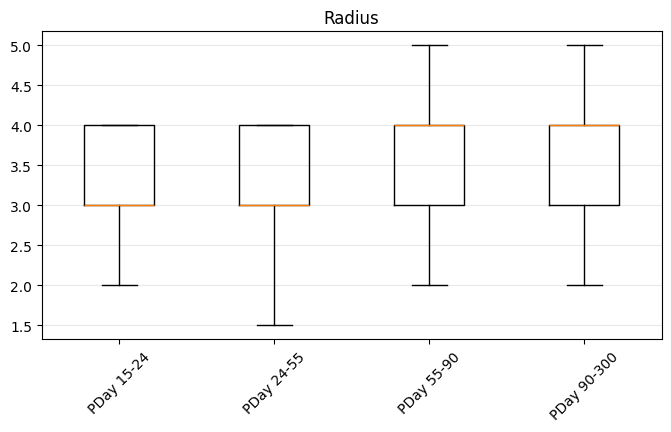

In [45]:
ax = nb_plotting.boxplot_summary({"NA": radius[CONNECT_THRESH]}, showfliers=False)
plt.gcf().set_size_inches(8, 4)
ax.set_title("connect_thresh={:.1f}".format(CONNECT_THRESH))
plt.title("Radius")
plt.savefig("plots/radius_boxplot.png", dpi=300)
plt.show()

In [46]:
fig = px.line(summaries_df_connect_thresh, x="dev_stage", y="radius", color="animal_id")
fig.show()

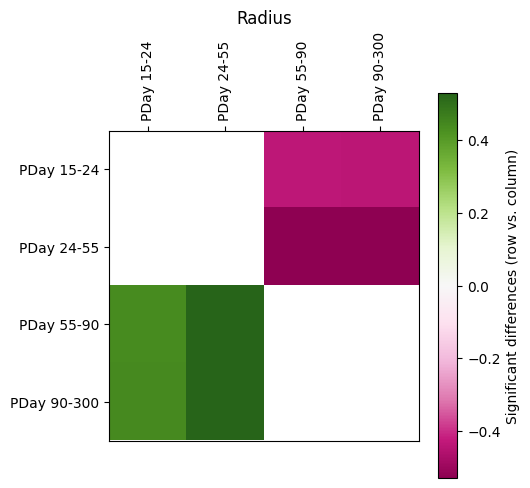

In [47]:
ax, results = permutation_tests.plot_stat_diff(
    radius[CONNECT_THRESH],
    return_all=True,
)
ax.set_title("Radius")
plt.savefig("plots/radius_permutation_test.png", dpi=300)
plt.show()

In [48]:
nb_utils.format_table_of_passed_tests(results)

,pair,test_stat,p_val
0,PDay 15-24 vs. PDay 55-90,-0.436978,0.003196
1,PDay 15-24 vs. PDay 90-300,-0.440260,0.003596
2,PDay 24-55 vs. PDay 55-90,-0.525911,0.001199
3,PDay 24-55 vs. PDay 90-300,-0.529193,0.001998


### Diameter (of the largest connected component)


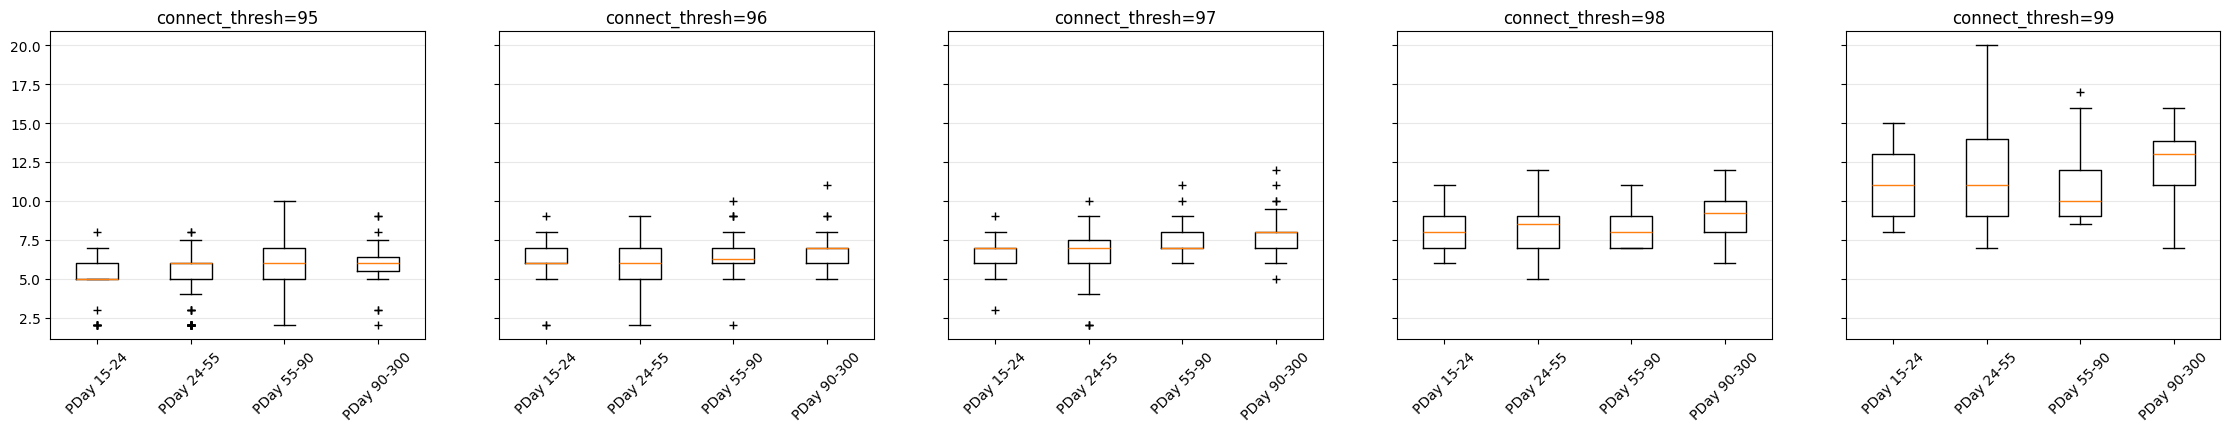

In [49]:
ax = nb_plotting.boxplot_summary(diameter)
plt.show()

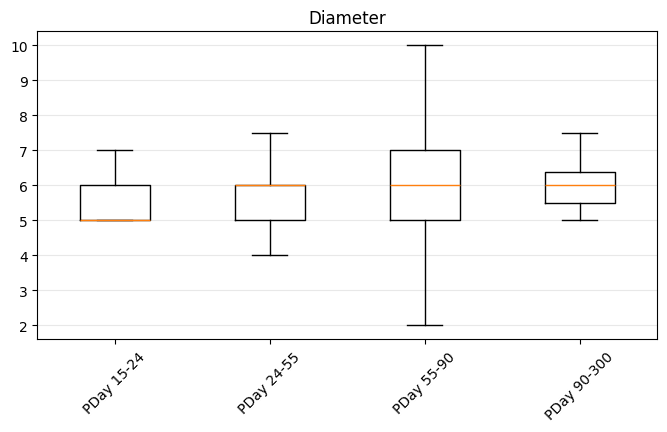

In [50]:
ax = nb_plotting.boxplot_summary({"NA": diameter[CONNECT_THRESH]}, showfliers=False)
plt.gcf().set_size_inches(8, 4)
ax.set_title("connect_thresh={:.1f}".format(CONNECT_THRESH))
plt.title("Diameter")
plt.savefig("plots/diameter_boxplot.png", dpi=300)
plt.show()

In [51]:
fig = px.line(
    summaries_df_connect_thresh, x="dev_stage", y="diameter", color="animal_id"
)
fig.show()

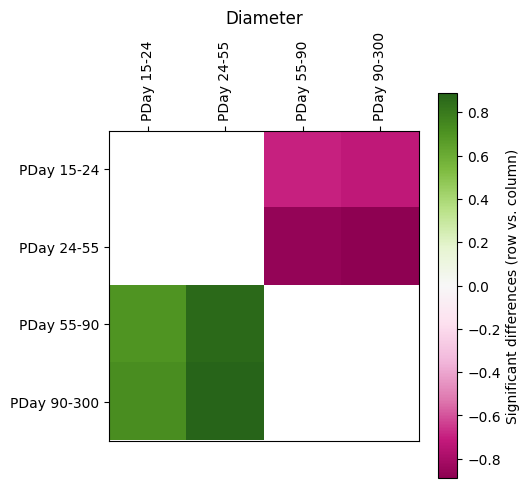

In [52]:
ax, results = permutation_tests.plot_stat_diff(
    diameter[CONNECT_THRESH],
    return_all=True,
)
ax.set_title("Diameter")
plt.savefig("plots/diameter_permutation_test.png", dpi=300)
plt.show()

In [53]:
nb_utils.format_table_of_passed_tests(results)

,pair,test_stat,p_val
0,PDay 15-24 vs. PDay 55-90,-0.698403,0.017299
1,PDay 15-24 vs. PDay 90-300,-0.722727,0.010360
2,PDay 24-55 vs. PDay 55-90,-0.864806,0.001199
3,PDay 24-55 vs. PDay 90-300,-0.889130,0.001199


### Median page rank


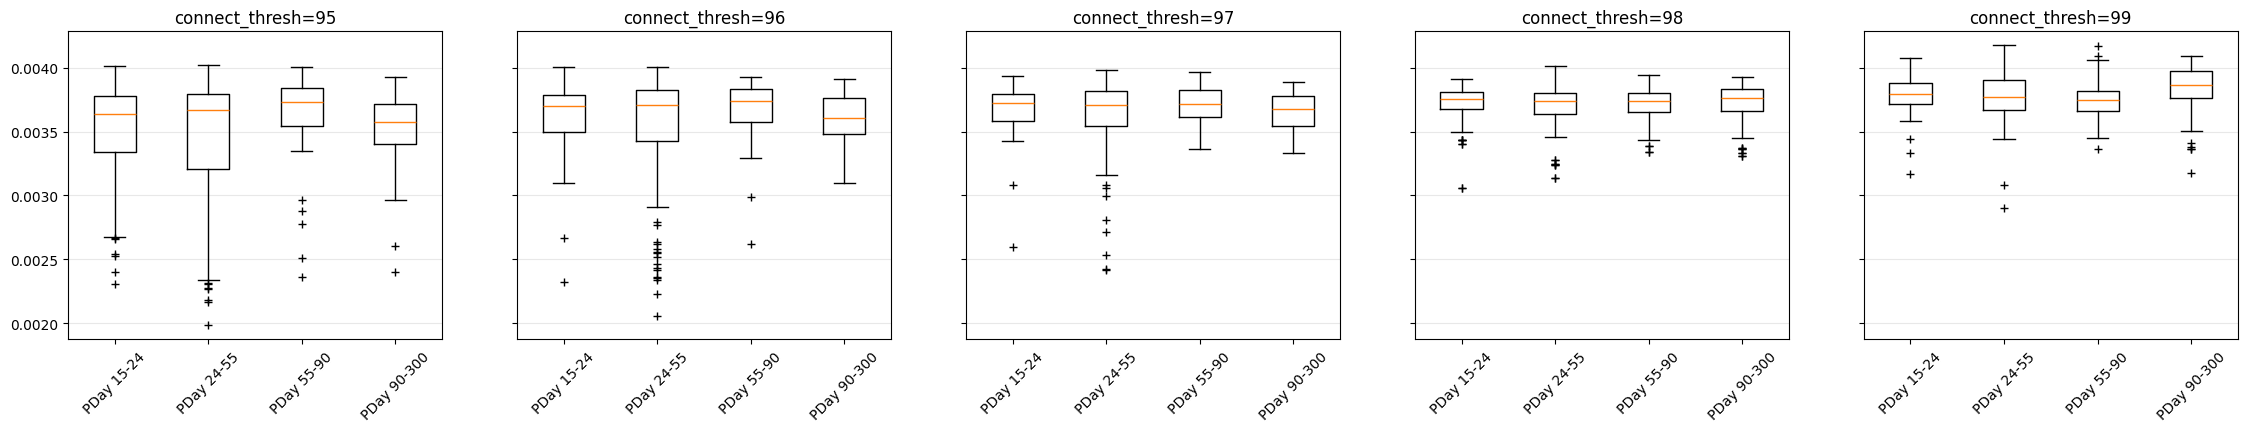

In [54]:
ax = nb_plotting.boxplot_summary(median_page_rank)
plt.show()

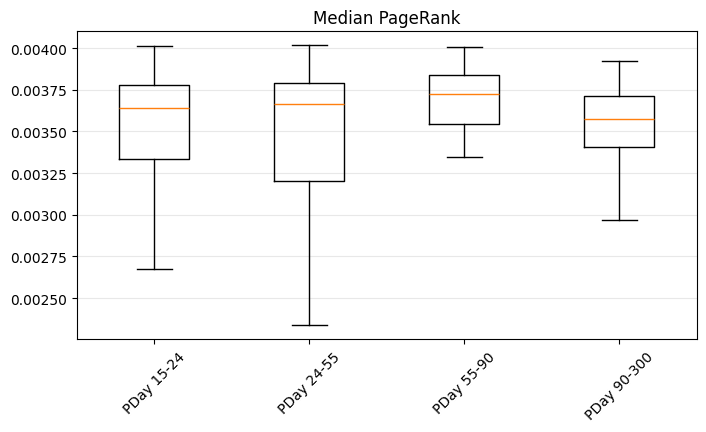

In [55]:
ax = nb_plotting.boxplot_summary(
    {"NA": median_page_rank[CONNECT_THRESH]}, showfliers=False
)
plt.gcf().set_size_inches(8, 4)
ax.set_title("connect_thresh={:.1f}".format(CONNECT_THRESH))
plt.title("Median PageRank")
plt.savefig("plots/median_page_rank_boxplot.png", dpi=300)
plt.show()

In [56]:
fig = px.line(
    summaries_df_connect_thresh, x="dev_stage", y="median_page_rank", color="animal_id"
)
fig.show()

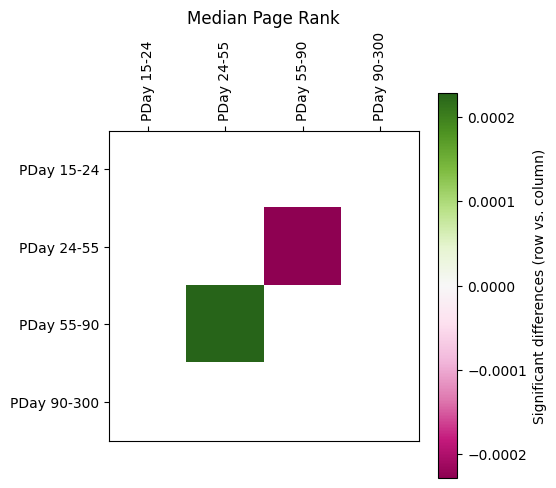

In [57]:
ax, results = permutation_tests.plot_stat_diff(
    median_page_rank[CONNECT_THRESH],
    return_all=True,
)
ax.set_title("Median Page Rank")
plt.savefig("plots/median_page_rank_permutation_test.png", dpi=300)
plt.show()

In [58]:
nb_utils.format_table_of_passed_tests(results)

,pair,test_stat,p_val
0,PDay 24-55 vs. PDay 55-90,-0.000228,0.005985


## Illustrating developmental windows and properties that stand out

In this section we will illustrate graphs typical of the network summaries that stand out. Pairs of developmental windows are chosen based on largest effect size between the summary distributions of windows being compared.

Let us create our dataset object to load data from:


In [59]:
animal_dataset = dataset.AnimalDataset(DATA_DIR)

And restrict the summaries table only to the connection threshold of interest:


In [60]:
# Restrict summaries to the connectivity threshold of interest
connect_thresh_grouping = summaries_df.groupby("connect_thresh")
restricted_df = connect_thresh_grouping.get_group(CONNECT_THRESH)

Choose a property and two developmental windows to compare


In [61]:
property = "transitivity"
dev_window_1 = [90, 300]
dev_window_2 = [15, 24]

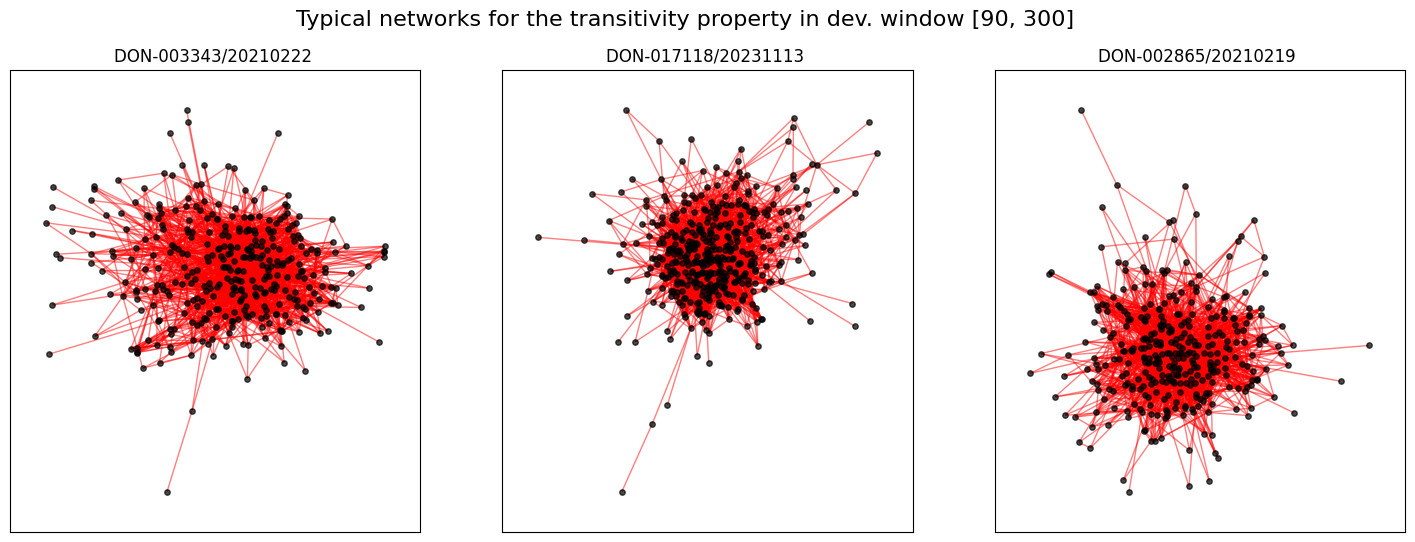

In [62]:
typical_samples = nb_utils.get_typical_samples(
    restricted_df,
    summary_name=property,
    dev_window=dev_window_1,
)
typical_networks = nb_utils.build_networks(
    animal_dataset,
    typical_samples,
    sim_type=SIMILARITY_METHOD,
    connect_thresh=CONNECT_THRESH,
)
fig, axs = plotting.networks_side_by_side(typical_networks, min_cc_size=10)
fig.suptitle(
    "Typical networks for the {} property in dev. window {}".format(
        property, dev_window_1
    ),
    fontsize=16,
)
plt.show()

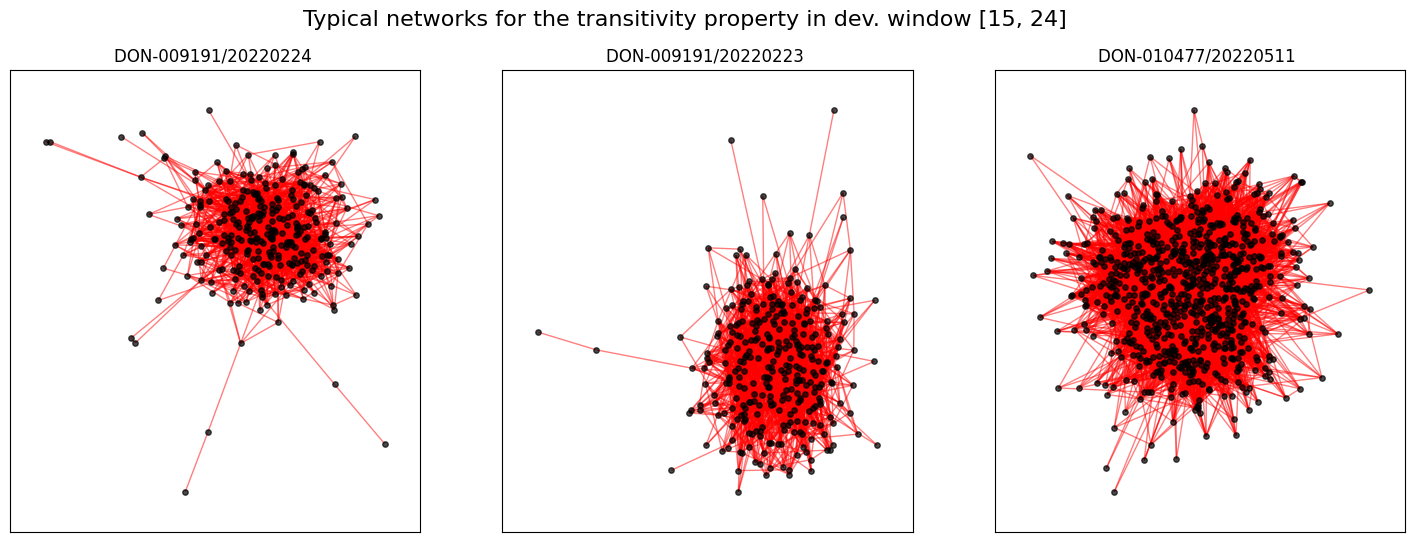

In [63]:
typical_samples = nb_utils.get_typical_samples(
    restricted_df,
    summary_name=property,
    dev_window=dev_window_2,
)
typical_networks = nb_utils.build_networks(
    animal_dataset,
    typical_samples,
    sim_type=SIMILARITY_METHOD,
    connect_thresh=CONNECT_THRESH,
)
fig, axs = plotting.networks_side_by_side(typical_networks, min_cc_size=10)
fig.suptitle(
    "Typical networks for the {} property in dev. window {}".format(
        property, dev_window_2
    ),
    fontsize=16,
)
plt.show()

# Link predictability comparisons

Comparing how easy it is to predict links in neural activity networks of mice across different development stage windows.


In [64]:
import os
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import nb_config
import nb_plotting
import nb_utils
import pandas as pd

from ngmd import dataset, graphs, plotting, utils
from ngmd import structural_consistency as sc

%reload_ext autoreload
%autoreload 2

warnings.simplefilter(action="ignore", category=FutureWarning)

# Dataset path as a global variable. Remember to set the correct path to the
# dataset in `notebooks/nb_config.py`
DATA_DIR = nb_config.DATA_DIR

# Models path as a global variable. Remember to set the correct path to the
# models folder in `notebooks/nb_config.py`
MODELS_DIR = nb_config.MODELS_DIR

# Path to directory with pre-computed analysis files
ANALYSIS_DIR = os.path.join(DATA_DIR, "analysis_files")

# Choose a similarity computation method
# SIMILARITY_METHOD = "zscores"
SIMILARITY_METHOD = "sttc_percentiles"

# Set a global connectivity threshold
CONNECT_THRESH = nb_utils.select_default_connect_thresh(SIMILARITY_METHOD)

# Keep results only for sessions marked as "good" in the dataset. Sessions that were marked as bad are those for which at least some of the analysis metrics were to far away from what one would see the days right before and after. You can still load the results for all sessions by setting the variable below to False.
KEEP_ONLY_GOOD_SESSIONS = True
# KEEP_ONLY_GOOD_SESSIONS = False

# Load results for subsampled networks. Set this to None to load the results for
# the full networks in each session.
SUBSAMPLE_SIZE = 250
# SUBSAMPLE_SIZE = None

Get all the animal IDs in the dataset


In [65]:
animal_dataset = dataset.AnimalDataset(DATA_DIR)
for animal in animal_dataset.animals:
    print(animal.animal_id)

DON-002865
DON-003165
DON-003343
DON-006084
DON-006085
DON-006087
DON-008497
DON-008498
DON-008499
DON-009191
DON-009192
DON-010473
DON-010477
DON-014837
DON-014838
DON-014840
DON-014847
DON-014849
DON-015078
DON-015079
DON-017115
DON-017117
DON-017118
DON-019207
DON-019210
DON-019213
DON-019542
DON-019545
DON-019608
DON-019609
DON-019747
DON-019748


Choose an example session


In [66]:
example_id = "DON-006084"
mouse_example = animal_dataset.get_animal_from_id(example_id)
example_session = mouse_example.get_session_from_date("20210519")
print("Animal ID: {}".format(example_session.animal_id))
print("Session date: {}".format(datetime.strptime(example_session.date, "%Y%m%d")))

Animal ID: DON-006084
Session date: 2021-05-19 00:00:00


Build a network from the example session's data


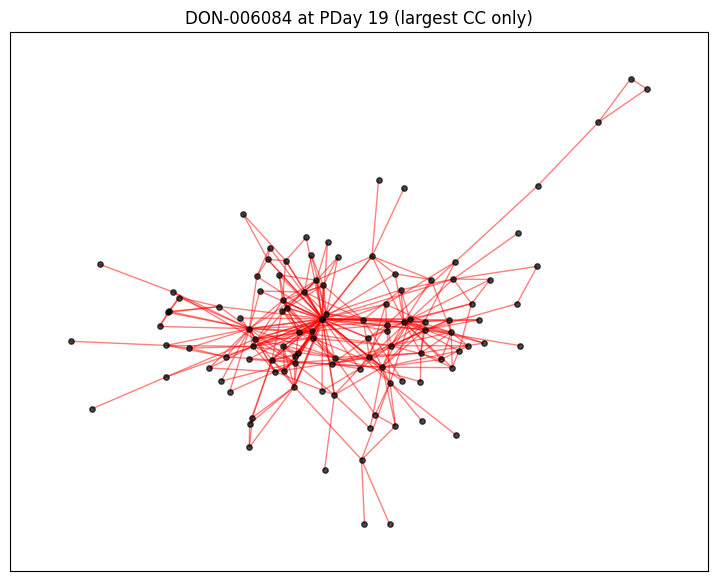

In [67]:
sim_mat = utils.select_sim_mat(example_session, SIMILARITY_METHOD)
example_sg = graphs.SimilarityGraph(sim_mat, connect_thresh=CONNECT_THRESH)

# Choose which (sub)graph to plot
largest_cc_only = True  # Plot only the largest connected component
if largest_cc_only:
    G = graphs.largest_cc(example_sg.G_nx)  # Largest connected component
else:
    G = example_sg.G_nx  # The whole graph

# Plot the graph
ax = plotting.plot_nx_graph(G)
title = "{} at PDay {}".format(example_id, example_session.dev_stage)
if largest_cc_only:
    title += " (largest CC only)"
ax.set_title(title)
plt.show()

## How predictable are the links in a network? The structural consistency perspective

[(Lü et al., 2015)](https://pnas.org/doi/full/10.1073/pnas.1424644112) define structural consistency as a way to estimate how predictable the links in a network are. The idea is that links are harder to predict if their removal causes large structural changes in the network. The structural consistency metric is derived by removing links from the network uniformly at random, then trying to approximate the network's original adjacency matrix using the eigenvalues and eigenvectors of the perturbed adjacency matrix. If the approximation is good, in a well-defined sense, then the network has high structural consistency. This value is normalized, so that the lowest possible structural consistency is 0, and the highest possible is 1.


Erdös-Rényi (ER) network have low structural consistency, due to their random nature. Let us draw an ER network with 100 nodes and 0.1 link probability:


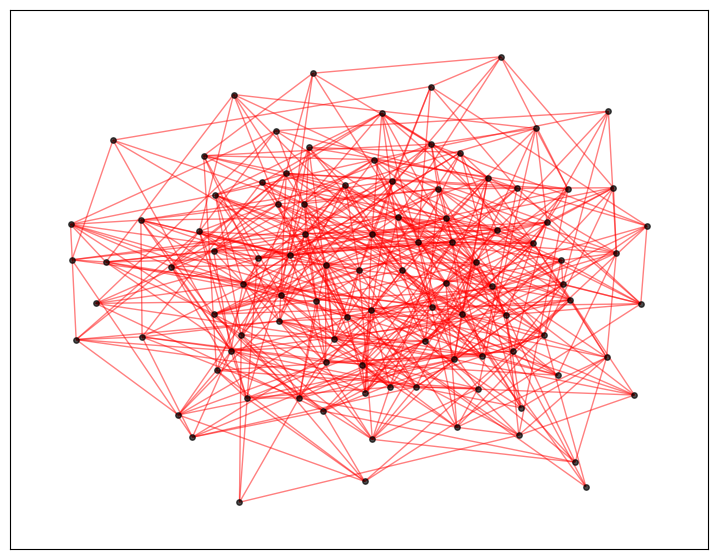

In [68]:
import networkx as nx

G_nx = nx.erdos_renyi_graph(100, 0.1)
plotting.plot_nx_graph(G_nx)
plt.show()

The structural consistency of ER(100, 0.1) should be close t 0.15. There are variations due to the random nature of the network and the random process defining the structural consistency metric.


In [69]:
sigma = sc.structural_consistency(G_nx, p_selection=0.1)
print(f"Structural consistency: {sigma:.4f}")

Structural consistency: 0.1538


This value gets only lower as we increase the number of nodes, meaning the links in the network get harder to predict.


In [70]:
# Draw an ER graph with 1000 nodes and p=0.1
G_nx = nx.erdos_renyi_graph(1000, 0.1)

sigma = sc.structural_consistency(G_nx, p_selection=0.1)
print(f"Structural consistency: {sigma:.4f}")

Structural consistency: 0.0291


Other classical random graphs are easier to predict. For example, the Watts-Strogatz (WS) model, which exhibits small-world characteristics, has higher structural consistency. Let us draw a WS network with 1000 nodes, average degree 6, and 0.1 rewiring probability:


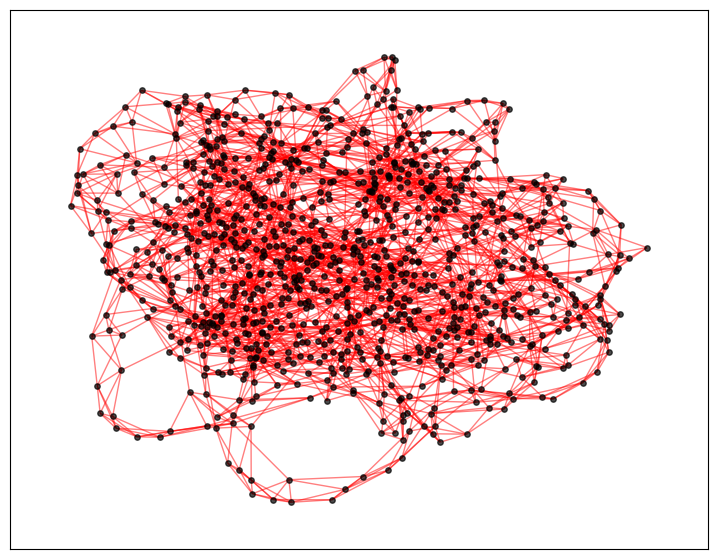

In [71]:
G_nx = nx.watts_strogatz_graph(1000, 6, 0.1)
plotting.plot_nx_graph(G_nx)
plt.show()

The structural consistency of WS(1000, 6, 0.1) should be close to 0.35 (once again, barring random variations).


In [72]:
# According to Lü et al. (2015), the structural consistency of WS(1000, 6, 0.1) should be close to 0.35
sigma = sc.structural_consistency(G_nx, p_selection=0.1)
print(f"Structural consistency: {sigma:.4f}")

Structural consistency: 0.3200


What is the structural consistency of the example graph from our dataset? Run the cell below a couple of times to get a sense of the variation


In [73]:
sigma = sc.structural_consistency(
    example_sg.G_nx,
    p_selection=0.1,
)
print(f"Structural consistency: {sigma:.4f}")

Structural consistency: 0.4857


With aid from the script `../scripts/structural_consistency.py`, we computed the structural consistency of all the networks in the dataset. To tame random variations, we computed the structural consistency of each network 20 times and recorded the average, standard deviation, 5th and 95th percentiles in that distribution. Here is how these results look like on a table.


In [74]:
# Load the pre-computed structural consistency results
file_name = "structural_consistency_{}".format(SIMILARITY_METHOD)
file_name += "_connect_thresh={:.1f}".format(CONNECT_THRESH)
if SUBSAMPLE_SIZE is not None:
    file_name += "_subsample_size={}".format(SUBSAMPLE_SIZE)
file_name += ".csv"
sc_df = pd.read_csv(os.path.join(ANALYSIS_DIR, file_name))

# Keep only the rows corresponding to "good" sessions
if KEEP_ONLY_GOOD_SESSIONS:
    sc_df = nb_utils.keep_rows_from_good_sessions(sc_df, animal_dataset)

sc_df.head()

,animal_id,session_date,dev_stage,mean_sc,std_sc,upper_sc,lower_sc
0,DON-014840,20230228,48,0.340945,0.035070,0.395530,0.285559
2,DON-014840,20230314,62,0.358816,0.035678,0.414672,0.304910
3,DON-014840,20230310,58,0.356150,0.037910,0.418140,0.294528
4,DON-014840,20230216,36,0.327154,0.033833,0.380397,0.269385
5,DON-014840,20230302,50,0.407409,0.038835,0.472637,0.346546


We can plot the structural consistency values as a function of developmental days:


In [75]:
# Sort the dataframe by animal ID and dev_stage
sc_df = sc_df.sort_values(by=["animal_id", "dev_stage"])

fig = nb_plotting.line_with_interval(
    data_frame=sc_df,
    x="dev_stage",
    y="mean_sc",
    error_y_mode="bands",
    error_y="std_sc",
    title="Structural consistency throughout development",
    color="animal_id",
)

fig.show()

In [76]:
# We can use the line below to update the table of bad sessions after looking at this
# day-by-day plot. The idea is to identify sessions whose metric is too far away from
# what was observe the days right before and after.

# nb_utils.update_bad_sessions(sc_df, "DON-015079", 24, animal_dataset)

Note that some animals display huge variation in the recorded structural consistency from day to day. To try to smooth out this variation, we can sort the developmental days into bins:


In [77]:
# Use the default development stage cuts
dev_stage_cuts = utils.get_default_dev_stage_cuts()

print("The selected development windows are:")
print("\n".join([label for label in nb_utils.labels_from_cuts(dev_stage_cuts)]))

The selected development windows are:
PDay 15-24
PDay 24-55
PDay 55-90
PDay 90-300


In [78]:
sc_dev_grouping = nb_utils.group_by_dev_interval(
    sc_df,
    dev_stage_cuts,
)

And now, compile the distribution of structural consistency values across all animals in each single bin:


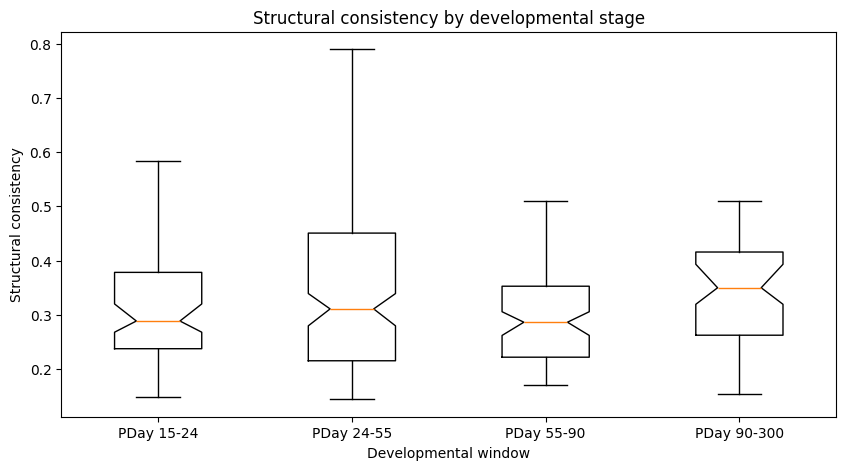

In [79]:
dev_window_values = []
dev_window_labels = []
for name, df in sc_dev_grouping:
    dev_window_values.append(df["mean_sc"].values)
    dev_window_labels.append(name)

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(
    dev_window_values,
    bootstrap=5000,
    notch=True,
    showfliers=False,
)
ax.set_xticklabels(dev_window_labels)
ax.set_ylabel("Structural consistency")
ax.set_xlabel("Developmental window")
ax.set_title("Structural consistency by developmental stage")
plt.savefig("plots/structural_consistency_by_dev_stage.png")
plt.show()

In [80]:
dev_window_labels

['PDay 15-24', 'PDay 24-55', 'PDay 55-90', 'PDay 90-300']

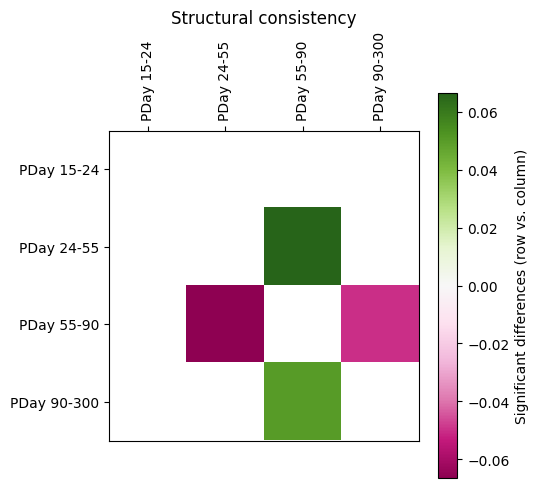

In [81]:
from ngmd import permutation_tests

structural_sonsistency = {}
for label, values in zip(dev_window_labels, dev_window_values):
    structural_sonsistency[label] = values

ax, results = permutation_tests.plot_stat_diff(
    structural_sonsistency,
    return_all=True,
)
ax.set_title("Structural consistency")
plt.savefig("plots/structural_consistency_permutation_test.png", dpi=300)
plt.show()

# Save results to XLSX

In [85]:
from ngmd.permutation_tests import pairwise_hypothesis_testing
import numpy as np
import xlsxwriter

# Your existing data preparation code
group_names = list(density[CONNECT_THRESH].keys())
data_labels = [
    "Number of connected components",
    "Size of largest connected component",
    "Density",
    "Transitivity",
    "Average shortest path length",
    "Average clustering coefficient",
    "Radius",
    "Diameter",
    "Median PageRank",
    "Structural consistency",
]
datas = [
    num_conn_comp,
    size_largest_cc,
    density,
    transitivity,
    avg_short_path_length,
    avg_clust,
    radius,
    diameter,
    median_page_rank,
    structural_sonsistency,
]

# Create Excel workbook
workbook = xlsxwriter.Workbook("results.xlsx")

# Define statistics order and names
stat_names = ["Mean", "Std", "Q1", "Q3", "Min", "Max", "Significant"]

# Create worksheets for each group
for group in group_names:
    worksheet = workbook.add_worksheet(group[:31])  # Sheet name limit

    # Write headers
    worksheet.write_row(0, 1, stat_names)  # Statistics across columns B-H
    worksheet.write_column(1, 0, data_labels)  # Data labels in column A

    # Process each metric
    for row_idx, (label, data) in enumerate(
        zip(data_labels, datas), 1
    ):  # Start at row 1
        if label == "Structural consistency":
            arr = data[group]
            pair_hypo_test = pairwise_hypothesis_testing(data)
        else:
            arr = data[CONNECT_THRESH][group]
            pair_hypo_test = pairwise_hypothesis_testing(data[CONNECT_THRESH])
        # Calculate statistics
        stats = [
            np.mean(arr),
            np.std(arr),
            np.percentile(arr, 25),
            np.percentile(arr, 75),
            np.min(arr),
            np.max(arr),
            pair_hypo_test,
        ]

        # Write statistics across columns
        for col_idx, value in enumerate(stats, 1):  # Start at column B
            if isinstance(value, float):
                worksheet.write(row_idx, col_idx, f"{value:.2f}")
            else:
                worksheet.write(row_idx, col_idx, str(value))

# Save text file (original format)
with open("results.txt", "w") as f:
    for group in group_names:
        f.write(f"{group}\n")
        for label, data in zip(data_labels, datas):
            if label == "Structural consistency":
                arr = data[group]
            else:
                arr = data[CONNECT_THRESH][group]
        f.write("\n")

workbook.close()